In [19]:
import pandas as pd
df=pd.read_excel(r"C:\Users\class\OneDrive\Documents\Movie Rating Analysis\Data\Raw\netflix_content_dataset.xlsx")

print("Shape of the dataset:", df.shape)
print(df.head(5))
print(df.tail(5))

#Check for Duplicates
print("Number of duplicate rows:", df.duplicated().sum())
#Drop duplicates
df.drop_duplicates(inplace=True)
print("Shape of the dataset after dropping duplicates:", df.shape)
print()

#Check for Missing Values
print("Missing values in each column:\n", df.isnull().sum())
#Drop subgenre column due to its unnecessary nature and high number of missing values
df.drop(columns=['subgenre'], inplace=True)
print("Shape of the dataset after dropping subgenre column:", df.shape)
#Fill missing values in IMDb rating with the mean rating
mean_rating = df['imdb_rating'].mean()
df['imdb_rating'] = df['imdb_rating'].fillna(mean_rating)
print("Missing values in each column after handling missing values:\n", df.isnull().sum())

print(df.info())
print(df.describe())
print(df.columns)
# Quick overview of categorical features
cat_summary = df.select_dtypes(include=['object', 'string']).nunique()
print(cat_summary)


# Save as Excel
df.to_excel(r"C:\Users\class\OneDrive\Documents\Movie Rating Analysis\Data\Cleaned\cleaned_netflix_dataset.xlsx", index=False)

Shape of the dataset: (50250, 16)
  content_id       title    type        genre       subgenre  language  \
0         C0   Last Last   Movie  Documentary          Crime    French   
1         C1  Life World  Series     Thriller      Adventure    German   
2         C2   Last Life  Series       Comedy          Crime  Japanese   
3         C3   Life Life   Movie      Romance  Psychological    French   
4         C4   Last Game   Movie       Comedy      Adventure    French   

  country_production  release_year  duration_minutes  imdb_rating  \
0        South Korea          2010                91          4.1   
1            Germany          1998                86          5.0   
2              Japan          1998               122          8.2   
3        South Korea          2022               108          7.7   
4              Japan          2020               145          7.2   

   popularity_score  total_views  avg_completion_rate age_rating  \
0             37.12      7982607      

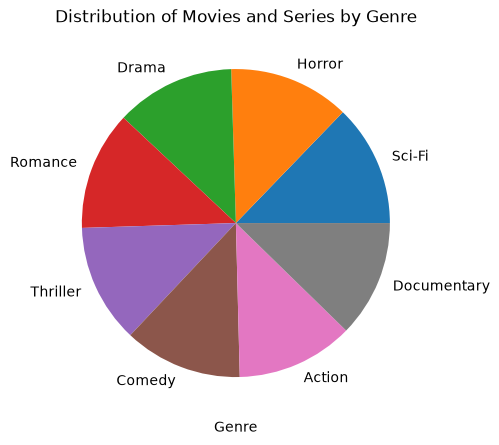

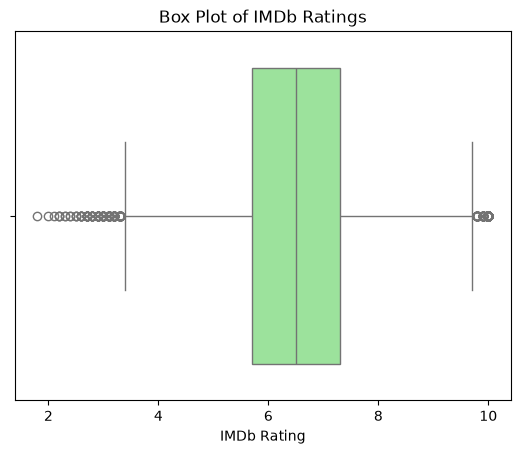

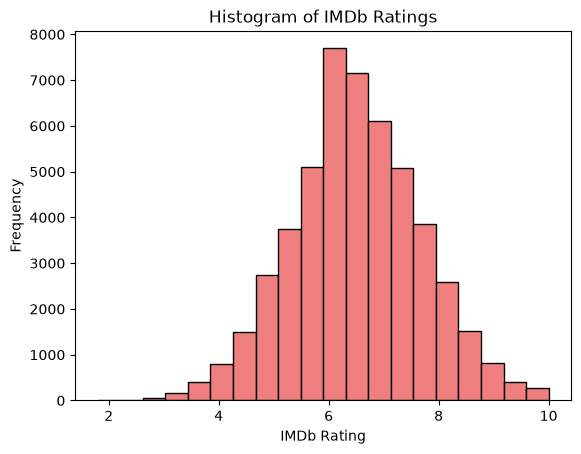

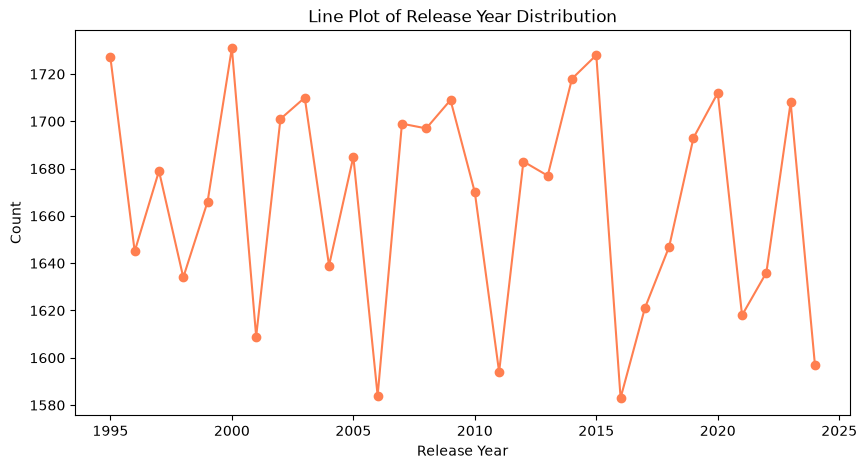

In [20]:
# Data Preparation Pipeline 
# Univariate Analysis 
import matplotlib.pyplot as plt
import seaborn as sns
 
# Pie Chart for genre distribution
df['genre'].value_counts().plot(kind='pie', figsize=(10,5), color='skyblue')
plt.title('Distribution of Movies and Series by Genre')
plt.xlabel('Genre')
plt.show()

#Box plot for IMDb rating distribution
sns.boxplot(x='imdb_rating', data=df, color='lightgreen')
plt.title('Box Plot of IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.show()

#histogram for IMDb rating distribution
plt.hist(df['imdb_rating'], bins=20, color='lightcoral', edgecolor='black')
plt.title('Histogram of IMDb Ratings')
plt.xlabel('IMDb Rating')
plt.ylabel('Frequency') 
plt.show()

#Line plot for release year distribution
df['release_year'].value_counts().sort_index().plot(kind='line', figsize=(10,5), marker='o', color='coral')
plt.title('Line Plot of Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

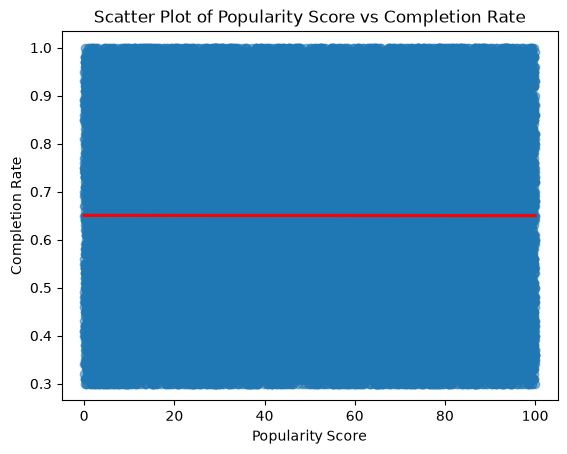

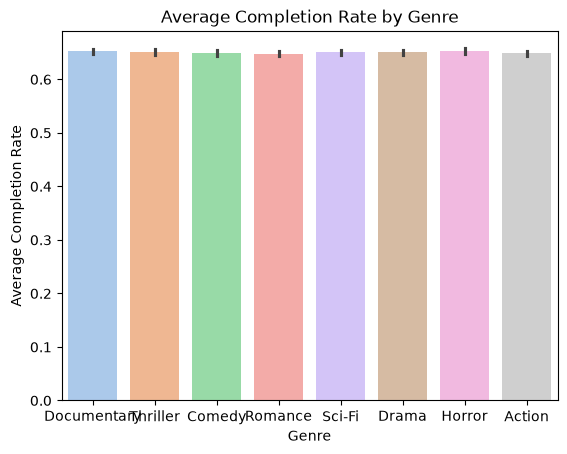

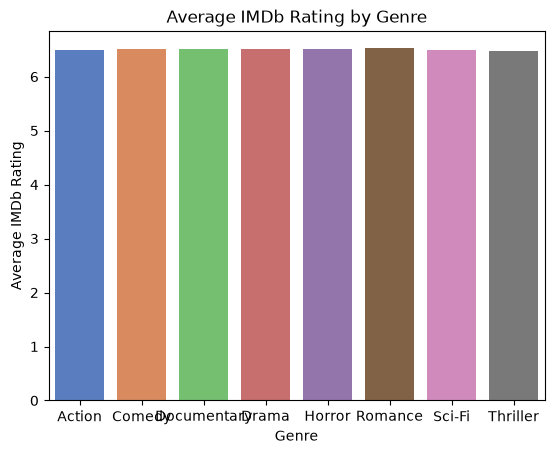

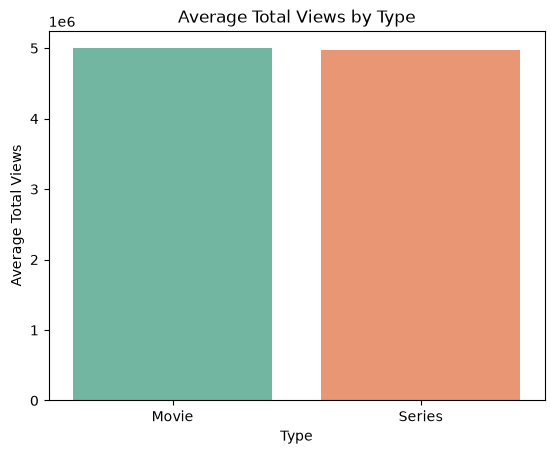

In [21]:
# Bivariate Analysis
# Scatter regression plot for popularity score vs completion rate  
sns.regplot(x='popularity_score', y='avg_completion_rate', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Scatter Plot of Popularity Score vs Completion Rate')
plt.xlabel('Popularity Score')
plt.ylabel('Completion Rate')
plt.show()

#Bar plot for average completion rate by genre
sns.barplot(x='genre', y='avg_completion_rate',data=df, palette='pastel',legend=False,hue='genre')
plt.title('Average Completion Rate by Genre')       
plt.xlabel('Genre')
plt.ylabel('Average Completion Rate')
plt.show()

#Bar plot for average IMDb rating by genre
avg_rating_by_genre = df.groupby('genre')['imdb_rating'].mean().reset_index()
sns.barplot(x='genre', y='imdb_rating', data=avg_rating_by_genre, palette='muted',legend=False,hue='genre')
plt.title('Average IMDb Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average IMDb Rating')
plt.show()  

#Bar plot for Type vs Total Views
avg_views_by_type = df.groupby('type')['total_views'].mean().reset_index()
sns.barplot(x='type', y='total_views', data=avg_views_by_type, palette='Set2',legend=False,hue='type')
plt.title('Average Total Views by Type')
plt.xlabel('Type')
plt.ylabel('Average Total Views')
plt.show()



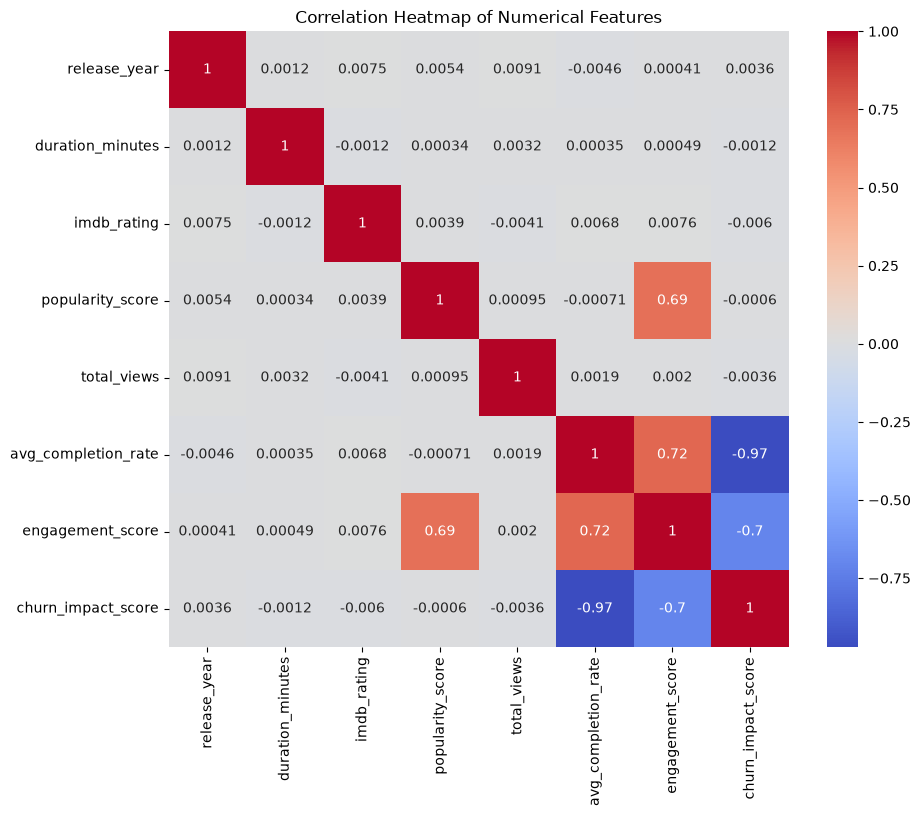

In [22]:
#Multivariate Analysis
#Correlation heatmap for numerical features
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(10,8))
corr=df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Key Observations
## 1. Strong Positive Correlations
-**Avg Completion Rate ↔ Engagement Score (0.72)**  
*Higher completion rates strongly align with higher engagement.* If viewers finish content, they’re more engaged.

-**Popularity Score ↔ Engagement Score (0.69)** 
 *Popular content tends to drive engagement.*

## 2. Strong Negative Correlations
-**Avg Completion Rate ↔ Churn Impact Score (-0.97)** 
 *The most critical insight: when completion rates are high, churn risk drops sharply.* This is almost a perfect inverse relationship.

-**Engagement Score ↔ Churn Impact Score (-0.70)** 
 Highly engaged users are much less likely to churn.

## 3. Weak / Near-Zero Correlations
-**Release Year with everything → near zero.**
 Year of release doesn’t strongly influence ratings, views, or engagement in this dataset.

-**Duration Minutes with other metrics → near zero.**
 Length of content doesn’t drive completion, views, or engagement here.

-**IMDb Rating with other metrics → very weak correlations.**
 Ratings don’t strongly predict popularity, views, or engagement.

# Interpretation 
-Engagement and completion rate are the strongest predictors of retention.

-Churn Impact Score is almost entirely explained by completion rate and engagement.

-Popularity helps engagement, but doesn’t directly reduce churn.

-Traditional metrics (release year, duration, IMDb rating) don’t add much predictive power.

# Business Takeaway
1. Focus on boosting completion rates → it directly lowers churn.

2. Use engagement score as an early warning system.

3. Don’t over‑rely on duration or IMDb rating; they’re not strong drivers here.

4. Retention strategy should prioritize content that maximizes completion and engagement.

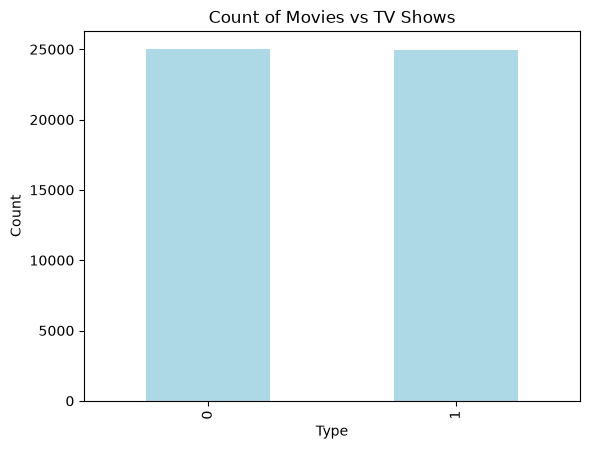

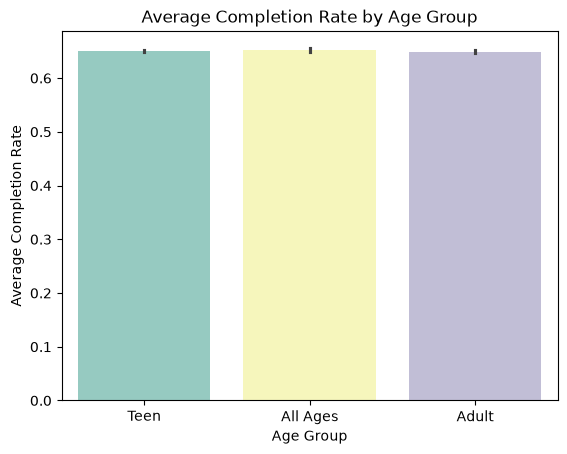

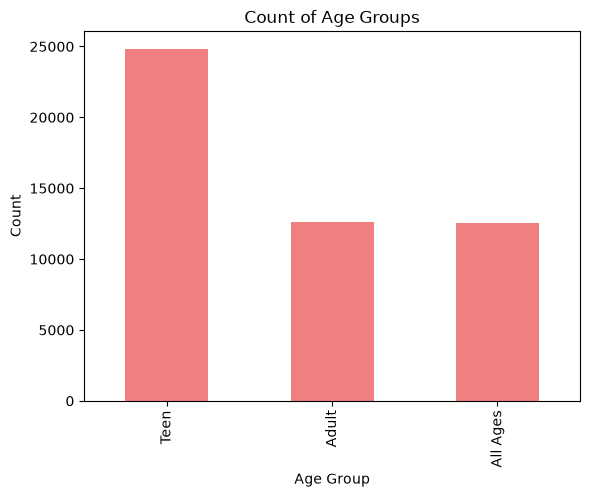

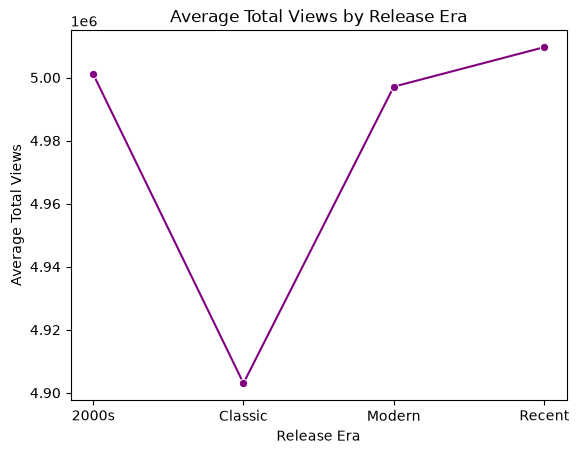

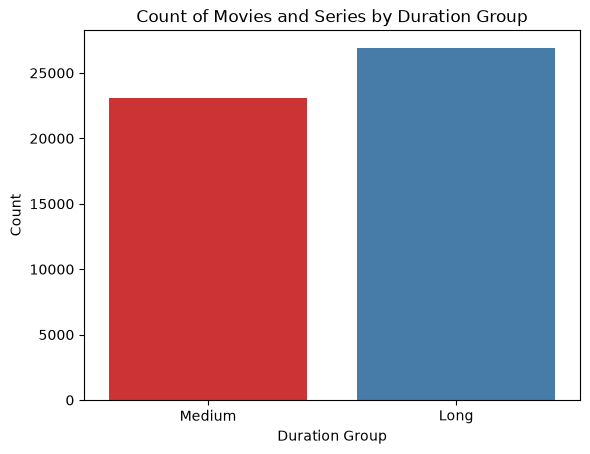

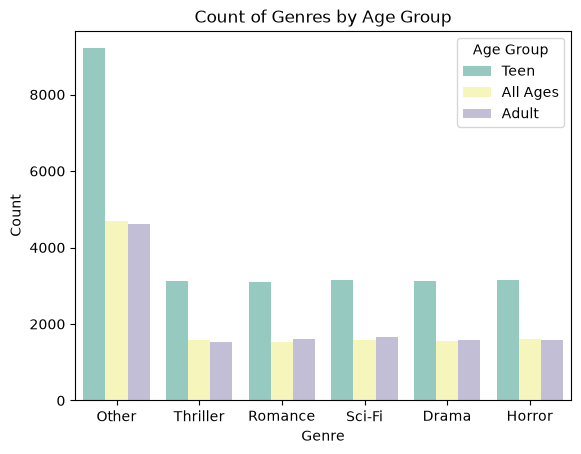

In [23]:
#Feature Engineering
#Binary encoding for type (Movie=1, TV Show=0)
df['type_encoded'] = df['type'].map({'Movie':0, 'Series':1})
df['type_encoded'].value_counts().plot(kind='bar', color='lightblue')
plt.title('Count of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

#Grouping Age rating into categories
def group_age(age_rating):
    if age_rating in ['18+']:
        return 'Adult'
    elif age_rating in ['PG-13','16+']:
        return 'Teen'
    else:
        return 'All Ages'
df['age_group'] = df['age_rating'].apply(group_age)
sns.barplot(x='age_group', y='avg_completion_rate', data=df, palette='Set3',legend=False,hue='age_group')
plt.title('Average Completion Rate by Age Group')       
plt.xlabel('Age Group')
plt.ylabel('Average Completion Rate')
plt.show()

df['age_group'].value_counts().plot(kind='bar', color='lightcoral')
plt.title('Count of Age Groups')        
plt.xlabel('Age Group')
plt.ylabel('Count') 
plt.show()

# Grouping release year into eras
def group_era(year):
    if year < 2000:
        return 'Classic'
    elif year < 2010:
        return '2000s'
    elif year < 2020:
        return 'Modern'
    else:
        return 'Recent'

df['release_era'] = df['release_year'].apply(group_era)
#LINE PLOT  for views by release era
views_by_era = df.groupby('release_era')['total_views'].mean().reset_index()
sns.lineplot(x='release_era', y='total_views', data=views_by_era, marker='o', color='purple')
plt.title('Average Total Views by Release Era') 
plt.xlabel('Release Era')       
plt.ylabel('Average Total Views')
plt.show()

#Duration Bins
def duration_bin(minutes):
    if minutes < 60:
        return 'Short'
    elif minutes <= 120:
        return 'Medium'
    else:
        return 'Long'

df['duration_group'] = df['duration_minutes'].apply(duration_bin)
#count plot for duration group
sns.countplot(x='duration_group', data=df, palette='Set1',hue='duration_group')
plt.title('Count of Movies and Series by Duration Group')
plt.xlabel('Duration Group')
plt.ylabel('Count')
plt.show()

#Grouping by Genre
genre_counts = df['genre'].value_counts()
top_genres = genre_counts.head(5).index  # pick top 5
def group_genre(g):
    if g in top_genres:
        return g
    else:
        return 'Other'

df['genre_group'] = df['genre'].apply(group_genre)

# Grouped Barplot for Genre per age category
sns.countplot(x='genre_group', hue='age_group', data=df, palette='Set3')
plt.title('Count of Genres by Age Group')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.legend(title='Age Group')
plt.show()

#Save the final cleaned and feature engineered dataset
df.to_excel(r"C:\Users\class\OneDrive\Documents\Movie Rating Analysis\Data\Cleaned\final_netflix_dataset.xlsx", index=False)


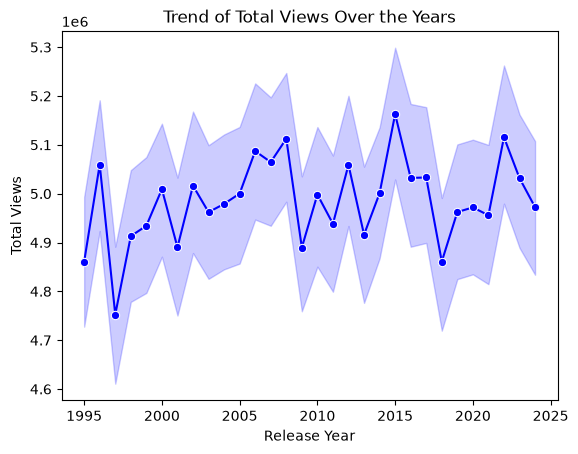

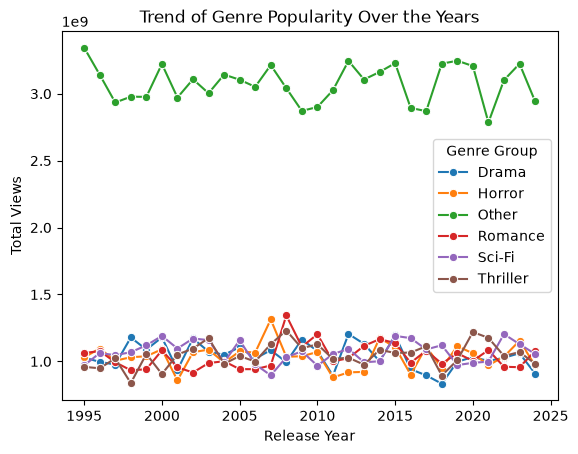

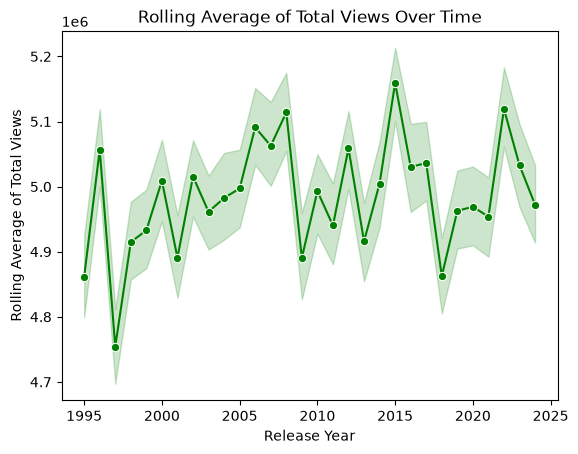

In [24]:
# Time Series Analysis
#Trend analysis of total views over the years
sns.lineplot(x='release_year', y='total_views', data=df, marker='o', color='blue')
plt.title('Trend of Total Views Over the Years')    
plt.xlabel('Release Year')
plt.ylabel('Total Views')
plt.show()

#Trend analysis of genre popularity over the years
genre_yearly_views = df.groupby(['release_year', 'genre_group'])['total_views'].sum().reset_index() 
sns.lineplot(x='release_year', y='total_views', hue='genre_group', data=genre_yearly_views, marker='o')
plt.title('Trend of Genre Popularity Over the Years')   
plt.xlabel('Release Year')
plt.ylabel('Total Views')   
plt.legend(title='Genre Group')
plt.show()

#Rolling average of total views over time
df_sorted = df.sort_values('release_year')
df_sorted['rolling_avg_views'] = df_sorted['total_views'].rolling(window=5).mean()  
sns.lineplot(x='release_year', y='rolling_avg_views', data=df_sorted, marker='o', color='green')
plt.title('Rolling Average of Total Views Over Time')
plt.xlabel('Release Year')
plt.ylabel('Rolling Average of Total Views')
plt.show()


### 1.Trend of Total Views Over the Years
This line graph shows how total views have varied across release years (1995–2025).

The blue line with markers represents the actual total views per year.

The shaded region around the line indicates variability or confidence intervals, showing the uncertainty or spread in the data.

The trend is not strongly upward or downward — instead, it fluctuates with periodic rises and dips.

This suggests that audience interest is influenced by factors other than just release year (e.g., genre, duration, or external events), since no clear long‑term growth or decline is visible.

*In short: views remain relatively stable over time, with cyclical peaks and troughs rather than a consistent trend.*

### 2.Trend of Genre Popularity Over the Years
Each colored line represents a genre group (Drama, Horror, Romance, Sci‑Fi, Thriller, Other).

The “Other” category dominates consistently, with far higher total views than any single genre.

The main genres (Drama, Romance, Sci‑Fi, Thriller, Horror) fluctuate between similar ranges, showing no single genre overtakes “Other” across the years.

*This suggests that niche or less common genres (grouped as “Other” i.e Documentary) collectively drive most of the viewership, while individual genres remain secondary.*

### 3.Rolling Average of Total Views Over Time
The green line shows a smoothed trend of total views using a rolling average.

Peaks appear around 1995, 2005, 2015, and 2020, with dips in between.

*This indicates cyclical patterns in viewership rather than a steady rise or fall.*


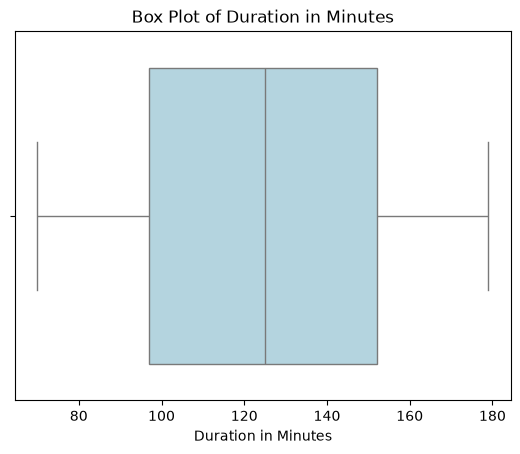

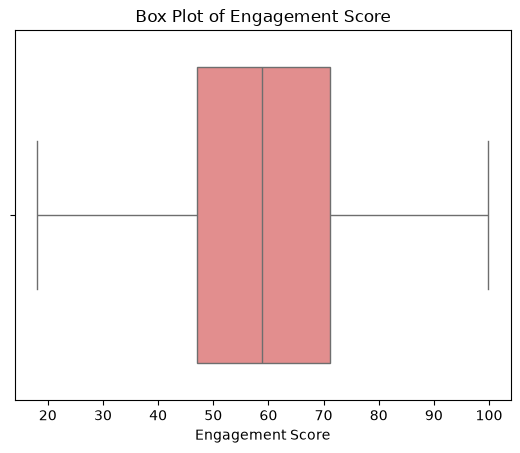

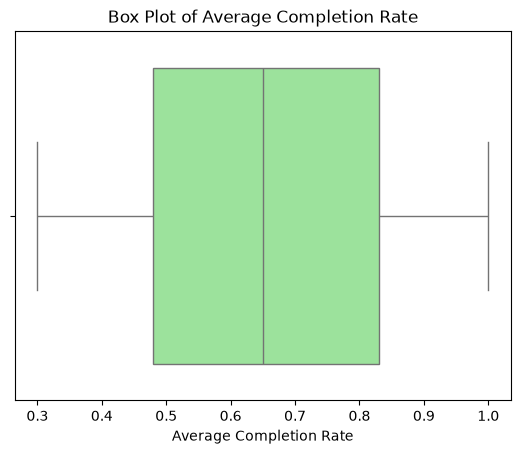

In [25]:
# Outlier Detection and Handling
# Outlier boxplot for duration_minutes
sns.boxplot(x='duration_minutes', data=df, color='lightblue')
plt.title('Box Plot of Duration in Minutes')
plt.xlabel('Duration in Minutes')
plt.show()

# Outlier boxplot for engagement score
sns.boxplot(x='engagement_score', data=df, color='lightcoral')
plt.title('Box Plot of Engagement Score')
plt.xlabel('Engagement Score')
plt.show()

# Outlier boxplot for completion rate
sns.boxplot(x='avg_completion_rate', data=df, color='lightgreen')
plt.title('Box Plot of Average Completion Rate')
plt.xlabel('Average Completion Rate')
plt.show()


### Box Plot of Duration (Minutes)
Interpretation: The median duration is around 130 minutes, with most values between ~80 and ~180 minutes. The distribution is fairly symmetric, showing a typical movie length range.

Conclusion: No significant outliers are present; durations cluster within expected bounds for standard content.

### Box Plot of Engagement Score
Interpretation: The median engagement score is ~60, with an interquartile range from ~50 to ~70. Whiskers extend from ~20 to ~100, covering the full spread of scores.

Conclusion: Engagement scores vary widely but remain within a reasonable range. No extreme outliers are detected.

### Box Plot of Average Completion Rate
Interpretation: The median completion rate is ~0.65, with most values between ~0.5 and ~0.8. Whiskers extend from ~0.3 to ~1.0, showing moderate variability.

Conclusion: Completion rates are generally consistent, with no abnormal values outside the expected 0–1 scale.